# packed_v1 leaderboard — visual weigh-in

Focused view of the `packed_v1` regime (canonical 4k-step horizon).

Two views:
1. **σ-anchored leaderboard** (bar chart): mean ± std per (optimizer, rank) cell, with AdamW's multi-seed σ-band as the reference. Single-seed cells render without error bars.
2. **Trajectory panel** (`standard_sweep_figure`): eval-loss curves over training, with AdamW's seed=0 η-sweep as the left-panel reference.

**σ_AdamW(packed_v1):** 0.0011 at r=16, 0.0017 at r=64 (from `adamw_multiseed_packed_4k_blackwell`, 4 seeds at η=3e-4 + seed=0 lr-sweep). All Δ claims in the writeups should be quoted in σ-units against this anchor.


In [82]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    standard_sweep_figure,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

## Audit — what's loadable vs invisible

In [84]:
print(render_inventory(inventory_runs('../logs')))

Loaded 170 of 178 groups on disk.

NO run_info/ (8) — files present but missing run_info/ dir, invisible to load_runs:
  adamw_sanity_packed_v1_4k
  bench
  bench_a100
  bench_profile_packed_v1
  bench_profile_walltime
  ddp_smoke
  integration_higham_test
  profile_polar_components

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 124 (optimizer, rank, mult) cells
PINNED at lr-range boundary (46) — extension sweep recommended:
  adam-clip-product-lora            r=16          best_lr=3e-04 (final=0.7555)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora            r=64          best_lr=3e-04 (final=0.7447)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=16          best_lr=3e-04 (final=0.7604)   swept=['3e-04', '1e-03'] → pinned_low
  adam-clip-product-lora-coupled-endrms  r=64          best_lr=3e-04 (final=0.74

## Load packed_v1 runs

Reference = AdamW lr-sweep (seed=0). Candidates = chord/polar variants at lr=3e-3.

In [85]:
# Reference: AdamW packed_v1, ALL seeds. With the multi-seed sweep landed,
# the library will:
#   - Aggregate per-η across seeds for the η-sweep curve (left panel,
#     vertical seed-σ error bars).
#   - Compute mean ± std trajectory at the best η across seeds for the
#     training-curve panel (right panel, shaded ±σ band around the mean).
ref_runs = load_runs(
    where={'optimizer': 'adamw', 'data_pipeline_version': 'packed_v1'},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'reference AdamW packed_v1 (all seeds): {len(ref_runs)} runs')
from collections import Counter
seed_count_per_lr = Counter((cfg['lr'], cfg.get('seed')) for cfg, _ in ref_runs)
print(f'  seeds per η: ' + ', '.join(
    f"η={lr:.0e}:{n}" for lr, n in
    Counter(cfg['lr'] for cfg, _ in ref_runs).most_common()))

# Candidates: packed_v1 runs in the chord/polar family at the canonical
# 4k horizon (drops old 500-step debug runs).
CHORD_FAMILY = [
    'adam-polar-product-lora-coupled-spectral-chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening',
    'adam-polar-product-lora-coupled-spectral-chord-direction',
    'adam-polar-product-lora-coupled',
]
cand_runs = load_runs(
    where={'optimizer': CHORD_FAMILY, 'data_pipeline_version': 'packed_v1',
           'max_steps': 4000},
    logs_root='../logs', warn_cross_commit=False,
)
print(f'candidate chord/polar packed_v1 @ 4k: {len(cand_runs)} runs')
for cfg, evs in cand_runs:
    last = evs[-1] if evs else {}
    pic = cfg.get('_derived', {}).get('effective_picard_iters')
    print(f"  {cfg['optimizer']:62s} r={cfg.get('lora_r')} lr={cfg.get('lr'):.0e} k={pic} "
          f"step={last.get('step')} eval={last.get('eval_loss'):.4f}")


reference AdamW packed_v1 (all seeds): 15 runs
  seeds per η: η=3e-04:9, η=1e-04:2, η=1e-03:2, η=3e-05:1, η=3e-03:1
candidate chord/polar packed_v1 @ 4k: 10 runs
  adam-polar-product-lora-coupled                                r=16 lr=3e-04 k=1 step=4000 eval=0.5257
  adam-polar-product-lora-coupled                                r=16 lr=3e-04 k=3 step=4000 eval=0.5235
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=16 lr=3e-03 k=1 step=4000 eval=0.5265
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=64 lr=3e-03 k=1 step=4000 eval=0.5159
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=16 lr=3e-03 k=3 step=4000 eval=0.5266
  adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening r=64 lr=3e-03 k=3 step=4000 eval=0.5160
  adam-polar-product-lora-coupled-spectral-chord-direction       r=16 lr=3e-03 k=3 step=4000 eval=0.5252
  adam-polar-product-lora-coupled-spectral-chord-direction       r=64 lr=3e-03 k=3 step=400

## Group key and color map

For AdaMuon-parent runs (no chord-tight ρ), distinguish by Picard iter count to separate the `frob_k=1` and `frob_k=3` cells. For chord-family variants the optimizer slug alone is the discriminator.

In [86]:
# Short legend labels — library uses the group_key string verbatim as the
# legend entry, so long optimizer slugs (60+ chars) would squash the plot
# area when the legend renders outside-right.
SHORT = {
    'adam-polar-product-lora-coupled-spectral-chord-tight':                'chord-tight',
    'adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening':   'chord-tight (no-whiten)',
    'adam-polar-product-lora-coupled-spectral-chord-direction':            'chord-direction (v1)',
}


def group_key(cfg):
    opt = cfg['optimizer']
    if opt == 'adam-polar-product-lora-coupled':
        k = cfg.get('_derived', {}).get('effective_picard_iters', '?')
        return f'frob k={k}'
    return SHORT.get(opt, opt)


color_map = {
    'chord-tight':
        OPTIM_COLORS['adam-polar-product-lora-coupled-spectral-chord-tight'],
    'chord-tight (no-whiten)':
        OPTIM_COLORS['adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening'],
    'chord-direction (v1)':
        OPTIM_COLORS.get(
            'adam-polar-product-lora-coupled-spectral-chord-direction',
            plt.cm.viridis(0.85),
        ),
    'frob k=1': plt.cm.cividis(0.30),
    'frob k=3': plt.cm.cividis(0.70),
}

marker_map = {
    'chord-tight':             OPTIM_MARKERS.get('adam-polar-product-lora-coupled-spectral-chord-tight', 'o'),
    'chord-tight (no-whiten)': OPTIM_MARKERS.get('adam-polar-product-lora-coupled-spectral-chord-tight-no-whitening', 's'),
    'chord-direction (v1)':    OPTIM_MARKERS.get('adam-polar-product-lora-coupled-spectral-chord-direction', 'D'),
    'frob k=1': '^',
    'frob k=3': 'v',
}


## Standard sweep figure

Library auto-splits by `lora_r` (one full 2-panel figure per rank), enforces the AdamW baseline overlay, and filters divergent runs above `DIVERGE_THRESHOLD`.

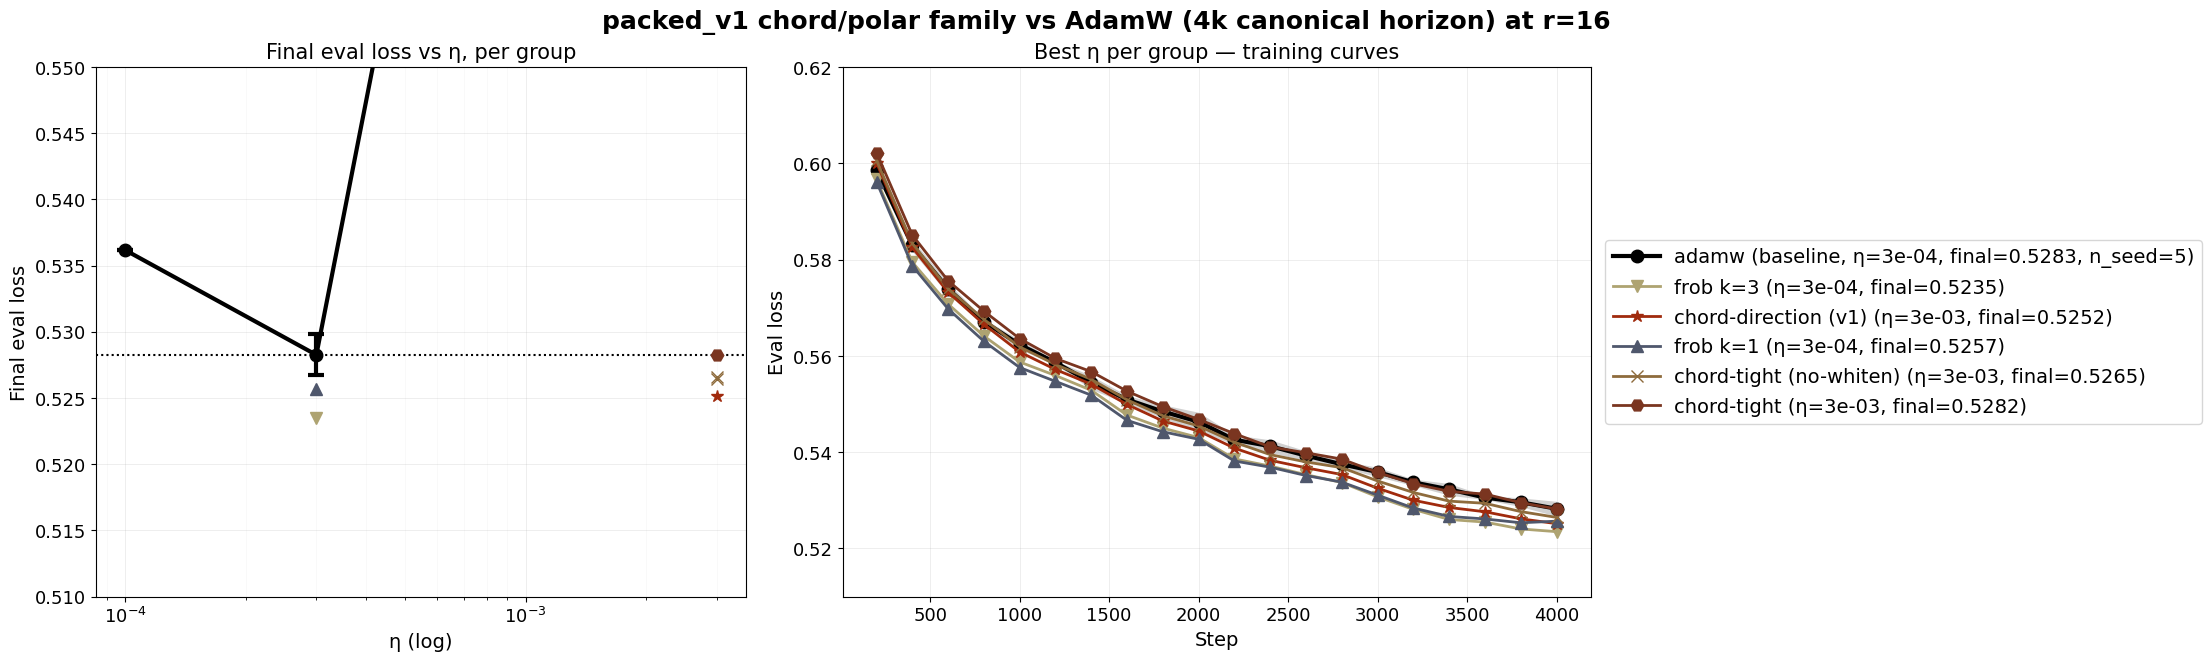

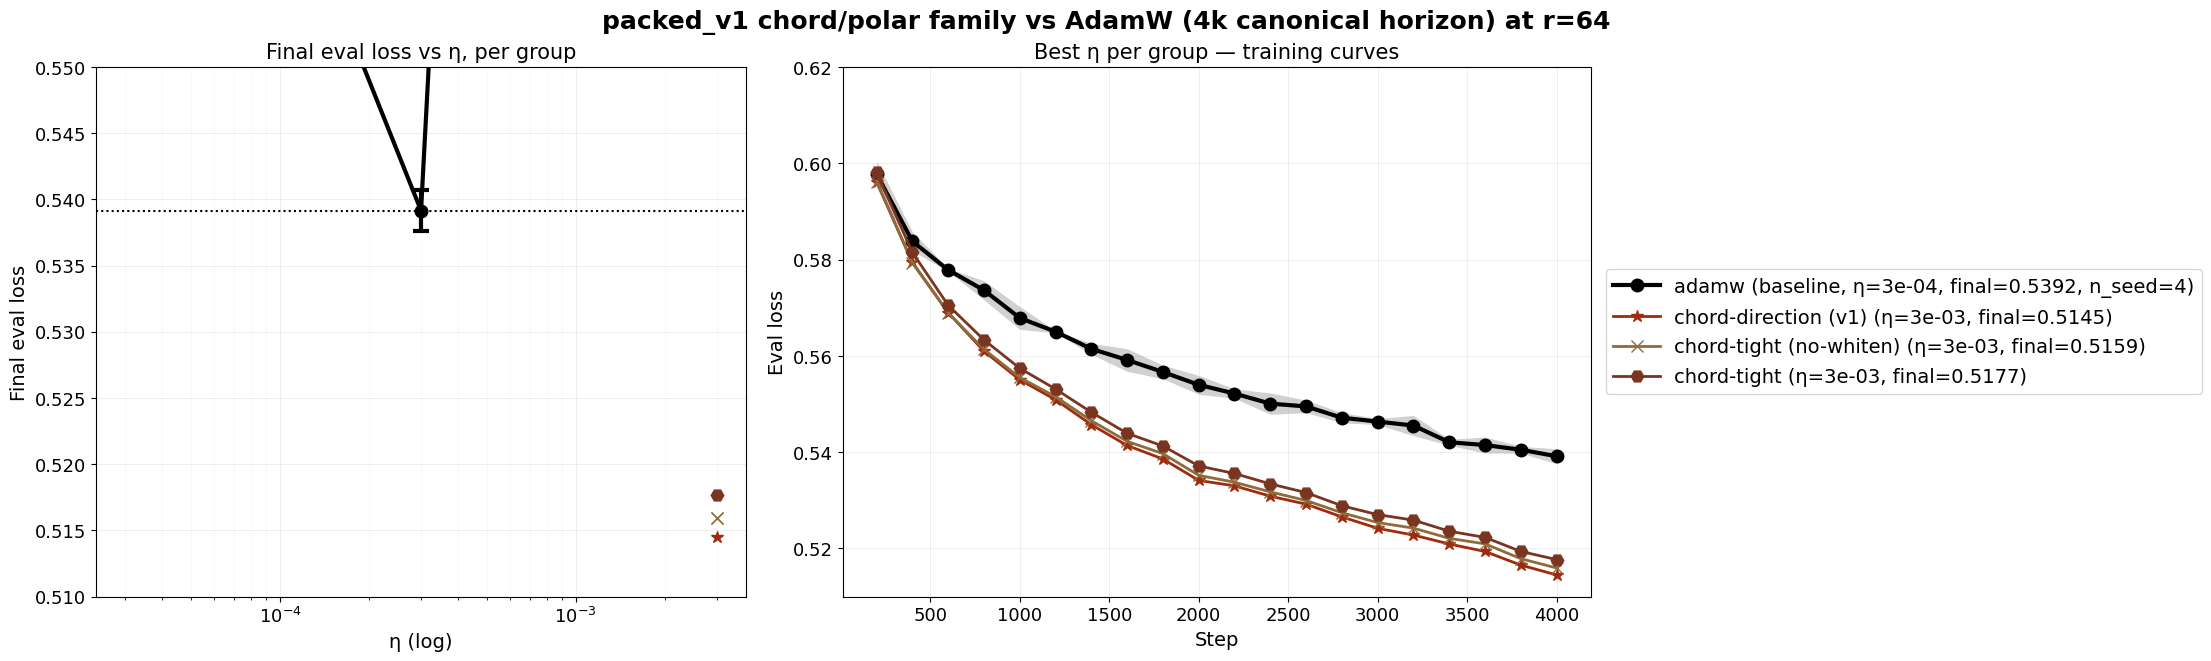

In [87]:
results = standard_sweep_figure(
    cand_runs,
    group_key_fn=group_key,
    color_map=color_map,
    reference_runs=ref_runs,
    suptitle='packed_v1 chord/polar family vs AdamW (4k canonical horizon)',
    same_value_axes=('lora_plus_multiplier',),
    marker_map=marker_map,
    figsize=(22, 6.5),
    x_tick_step=500,
)

# Different YLIMs per panel:
#   Left  (η vs final eval): TIGHT — needs to show AdamW σ ≈ 0.0011-0.0017
#     against Δ ≈ 0.001-0.005 from chord candidates. Off-optimum AdamW η
#     points (η=1e-3, 3e-3) clip off-frame; they don't inform Δ-vs-σ.
#   Right (training curves):  WIDE — needs to show the full descent from
#     ~0.60 at step 200 down to ~0.52 at step 4000. A tight ylim would
#     hide the first ~1000 steps.
YLIM_LEFT  = (0.510, 0.550)
YLIM_RIGHT = (0.510, 0.620)
for fig, axes, _n_keep, _n_drop in results:
    axes[0].set_ylim(*YLIM_LEFT)
    axes[1].set_ylim(*YLIM_RIGHT)

plt.show()
